# Notebook 4: Spatial Classification
This notebook will contain code for classification through spatial analysis, harnessing CNN architectures such as ResNet for this task.


Here, we want to try and answer:
> Can spatial information compensate for reduced spectral information?

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Sampler

import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes, closing, opening, disk

# --- Colab path setup ---

RUN_IN_COLAB = True   # set False locally

if RUN_IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    import sys
    from pathlib import Path

    THESIS_ROOT = Path("/content/drive/MyDrive/Masters/Thesis")
    DATASET_ROOT = THESIS_ROOT / "dataset"

    sys.path.append(str(THESIS_ROOT))

    print("Thesis root:", THESIS_ROOT)
    print("Dataset root:", DATASET_ROOT)
    print("hsi_utils path:", THESIS_ROOT / "hsi_utils.py")

from hsi_utils import load_data, load_cube, build_foreground_mask, build_foreground_mask_auto

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Thesis root: /content/drive/MyDrive/Masters/Thesis
Dataset root: /content/drive/MyDrive/Masters/Thesis/dataset
hsi_utils path: /content/drive/MyDrive/Masters/Thesis/hsi_utils.py
Random seed set to 42


In [ ]:
# --- Remote data loading and CPU/GPU setup ---



DATASET_ROOT = Path(
    "/replace/this/with/the/remote/dataset/path"
)

train_files, valid_files, test_files, files_split = load_data(
    dataset_path=DATASET_ROOT,
    use_wsl_mount=False,
    varieties=("barley", "corn", "flax"),
)


# Class labels
varieties = ["barley", "corn", "flax"]

class_to_idx = {
    variety: index
    for index, variety in enumerate(varieties)
}

idx_to_class = {
    index: variety
    for variety, index in class_to_idx.items()
}


# Check loaded splits
required_columns = {
    "sample_name",
    "variety",
    "size",
    "rep",
    "split",
    "filepath_FX10",
}

missing_columns = (
    required_columns - set(files_split.columns)
)

if missing_columns:
    raise ValueError(
        "load_data() did not return the required columns. "
        f"Missing: {sorted(missing_columns)}"
    )

print("\nTrain images:", len(train_files))
print("Validation images:", len(valid_files))
print("Test images:", len(test_files))

display(
    files_split[
        [
            "sample_name",
            "variety",
            "size",
            "rep",
            "split",
            "filepath_FX10",
        ]
    ].head()
)


# Select CPU or GPU automatically
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nPyTorch version:", torch.__version__)
print("PyTorch CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("Selected device:", device)

if device.type == "cuda":
    gpu_index = torch.cuda.current_device()

    print("GPU index:", gpu_index)
    print(
        "GPU name:",
        torch.cuda.get_device_name(gpu_index),
    )

    total_memory_gb = (
        torch.cuda.get_device_properties(
            gpu_index
        ).total_memory
        / 1024**3
    )

    print(
        "Total GPU memory:",
        f"{total_memory_gb:.2f} GB",
    )

    # Improves convolution performance when input shapes are fixed.
    torch.backends.cudnn.benchmark = True

else:
    print(
        "A CUDA-capable GPU was not detected. "
        "The notebook will run on the CPU."
    )


# Optional nvidia-smi diagnostic
# This reports GPU/driver information but does not enable CUDA.
if device.type == "cuda":
    try:
        result = subprocess.run(
            ["nvidia-smi"],
            capture_output=True,
            text=True,
            check=True,
        )

        print("\n--- nvidia-smi ---")
        print(result.stdout)

    except FileNotFoundError:
        print(
            "\nnvidia-smi is unavailable, but PyTorch "
            "has detected the GPU successfully."
        )

    except subprocess.CalledProcessError as exc:
        print("\nnvidia-smi returned an error:")
        print(exc.stderr)


# DataLoader performance settings
PIN_MEMORY = device.type == "cuda"

NUM_WORKERS = 2

print("Pin memory:", PIN_MEMORY)
print("DataLoader workers:", NUM_WORKERS)


In [2]:
"""# --- Colab / local data loading switch ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU found.")


RUN_IN_COLAB = True   # set False when running locally

if RUN_IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    import h5py
    from pathlib import Path

    DATASET_ROOT = Path("/content/drive/MyDrive/Masters/Thesis/dataset")

    print("Dataset root:", DATASET_ROOT)


    all_files = list(DATASET_ROOT.rglob("*.hdf5"))
    print("Total .hdf5 files found:", len(all_files))

    df_files = pd.DataFrame({"filepath_FX10": all_files})
    df_files["sample_name"] = df_files["filepath_FX10"].apply(lambda p: p.stem)

    def resolve_valid_hdf5(path):
        try:
            with h5py.File(path, "r"):
                return path
        except Exception:
            return None

    df_files["resolved_path"] = df_files["filepath_FX10"].apply(resolve_valid_hdf5)
    df_valid = df_files[df_files["resolved_path"].notna()].copy()

    df_valid["variety"] = df_valid["sample_name"].str.split("_").str[0]
    df_valid["batch"] = df_valid["sample_name"].str.split("_").str[-1]
    df_valid["size"] = df_valid["batch"].str[0]
    df_valid["rep"] = df_valid["batch"].str[1:].astype(int)

    varieties = ["barley", "corn", "flax"]
    df_valid = df_valid[df_valid["variety"].isin(varieties)].copy()

    def assign_split(group):
        group = group.sort_values("rep").copy()
        group["split"] = "unused"
        group.iloc[:3, group.columns.get_loc("split")] = "train"
        group.iloc[3:4, group.columns.get_loc("split")] = "valid"
        group.iloc[4:5, group.columns.get_loc("split")] = "test"
        return group

    files_split = (
        df_valid
        .groupby(["variety", "size"], group_keys=False)
        .apply(assign_split)
        .reset_index(drop=True)
    )

    train_files = files_split[files_split["split"] == "train"].copy()
    valid_files = files_split[files_split["split"] == "valid"].copy()
    test_files = files_split[files_split["split"] == "test"].copy()

else:
    train_files, valid_files, test_files, files_split = load_data()
    varieties = ["barley", "corn", "flax"]

class_to_idx = {v: i for i, v in enumerate(varieties)}
idx_to_class = {i: v for v, i in class_to_idx.items()}

print("Train images:", len(train_files))
print("Valid images:", len(valid_files))
print("Test images:", len(test_files))

display(files_split[["sample_name", "variety", "size", "rep", "split"]].head())"""

Using device: cuda
GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset root: /content/drive/MyDrive/Masters/Thesis/dataset
Total .hdf5 files found: 45
Train images: 27
Valid images: 9
Test images: 9


/tmp/ipykernel_56354/250204691.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_split)


,sample_name,variety,size,rep,split
0,barley_l0,barley,l,0,train
1,barley_l1,barley,l,1,train
2,barley_l2,barley,l,2,train
3,barley_l3,barley,l,3,valid
4,barley_l4,barley,l,4,test


In [3]:
# From spectral_exploration.ipynb

ONE_WAVELENGTH_PCA = 668.8
THREE_WAVELENGTHS_PCA = [668.8, 666.0, 649.8]

ONE_WAVELENGTH_VIP = 398.8
THREE_WAVELENGTHS_VIP = [398.8, 401.3, 1001.9]

"""EXPERIMENTS = {
    "PCA 1-band CNN": [ONE_WAVELENGTH_PCA],
    "PCA 3-band CNN": THREE_WAVELENGTHS_PCA,
    "VIP 1-band CNN": [ONE_WAVELENGTH_VIP],
    "VIP 3-band CNN": THREE_WAVELENGTHS_VIP,
}"""

EXPERIMENTS = {
    "PCA 1-band CNN": [ONE_WAVELENGTH_PCA],
    "PCA 3-band CNN": THREE_WAVELENGTHS_PCA,
}

print(EXPERIMENTS)

{'PCA 1-band CNN': [668.8], 'PCA 3-band CNN': [668.8, 666.0, 649.8]}


In [4]:
# --- Image loading, masking, and foreground-only normalization ---

def percentile_normalize_foreground(img, mask=None, p_low=2, p_high=98):
    img = img.astype(np.float32)

    if mask is not None and mask.sum() > 0:
        values = img[mask > 0]
    else:
        values = img.reshape(-1)

    lo, hi = np.percentile(values, [p_low, p_high])
    img = (img - lo) / (hi - lo + 1e-6)
    img = np.clip(img, 0, 1)

    if mask is not None:
        img = img * mask

    return img.astype(np.float32)


def load_multiband_image(
    filepath,
    target_wavelengths,
    crop=True,
    apply_mask=True,
    true_label=None,
    size=None
):
    hcube, wlens, darkref, whiteref = load_cube(filepath)

    if crop:
        hcube = hcube[75:1025, 100:875, :]

    band_indices = [
        int(np.argmin(np.abs(wlens - wl)))
        for wl in target_wavelengths
    ]

    actual_wlens = [float(wlens[i]) for i in band_indices]

    if apply_mask:
        mask = build_foreground_mask_auto(
            hcube,
            size=size,
            true_label=true_label
        ).astype(np.float32)
    else:
        mask = np.ones(hcube.shape[:2], dtype=np.float32)

    channels = []

    for idx in band_indices:
        band_img = hcube[:, :, idx].astype(np.float32)
        band_img = percentile_normalize_foreground(band_img, mask=mask)
        channels.append(band_img)

    img = np.stack(channels, axis=-1)

    return img, mask, band_indices, actual_wlens


 PCA 1-band CNN [668.8]


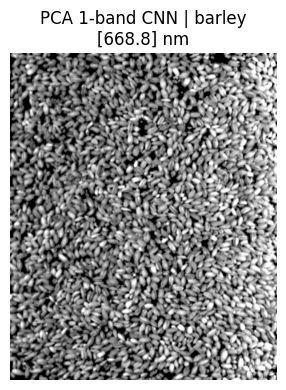

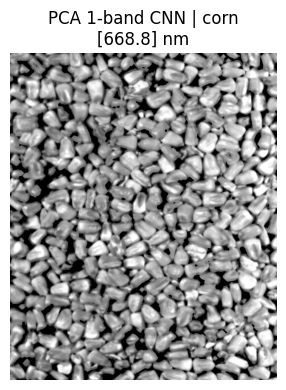

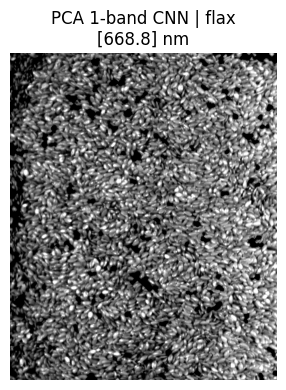


 PCA 3-band CNN [668.8, 666.0, 649.8]


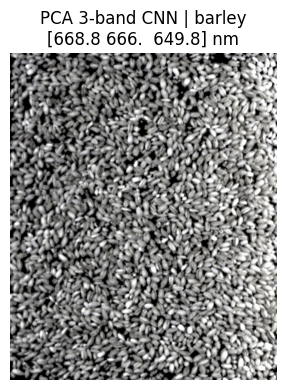

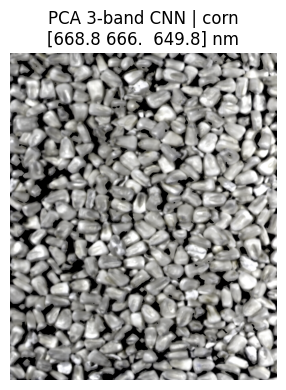

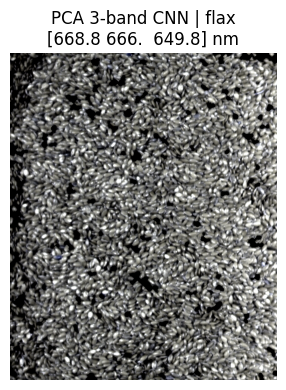

In [5]:
# --- Preview PCA and VIP selected bands ---

for experiment_name, wavelengths in EXPERIMENTS.items():

    print("\n", experiment_name, wavelengths)

    for var in varieties:
        subset = train_files[train_files["variety"] == var]

        if subset.empty:
            continue

        row = subset.iloc[0]

        img, mask, band_indices, actual_wlens = load_multiband_image(
            row["filepath_FX10"],
            target_wavelengths=wavelengths,
            true_label=row["variety"],
            size=row["size"]
        )

        plt.figure(figsize=(5, 4))

        if img.shape[-1] == 1:
            plt.imshow(img[:, :, 0], cmap="gray")
        else:
            plt.imshow(img)

        plt.title(f"{experiment_name} | {var}\n{np.round(actual_wlens, 1)} nm")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

In [6]:
# --- Foreground-aware tiling with gaps between tiles ---

def make_spaced_tiles_multichannel(
    img,
    mask,
    n_rows=4,
    n_cols=4,
    tile_h=220,
    tile_w=180
):
    """
    Extract fixed-size tiles with space between neighbouring tiles.

    For a 4x4 layout:
    - each tile is 220 x 180 pixels;
    - tile starting positions are spread evenly across the image;
    - unused pixels therefore become gaps between tiles;
    - no resizing or stretching is performed.
    """
    H, W, C = img.shape

    required_h = n_rows * tile_h
    required_w = n_cols * tile_w

    if H < required_h or W < required_w:
        raise ValueError(
            f"Image shape {(H, W)} is too small for "
            f"{n_rows}x{n_cols} tiles of size {tile_h}x{tile_w}."
        )

    # Evenly distribute tile starts from one image boundary to the other.
    # The remaining pixels become gaps between adjacent tiles.
    y_starts = np.linspace(
        0,
        H - tile_h,
        n_rows,
        dtype=int
    )

    x_starts = np.linspace(
        0,
        W - tile_w,
        n_cols,
        dtype=int
    )

    tiles = []
    foreground_fractions = []
    positions = []

    for r, y0 in enumerate(y_starts):
        for c, x0 in enumerate(x_starts):
            y1 = y0 + tile_h
            x1 = x0 + tile_w

            tile = img[y0:y1, x0:x1, :]
            tile_mask = mask[y0:y1, x0:x1]

            tiles.append(tile)
            foreground_fractions.append(float(tile_mask.mean()))
            positions.append((y0, y1, x0, x1))

    foreground_fractions = np.asarray(
        foreground_fractions,
        dtype=np.float32
    )

    assert len(tiles) == n_rows * n_cols
    assert all(tile.shape == (tile_h, tile_w, C) for tile in tiles)

    # Report approximate spacing for checking.
    vertical_gaps = np.diff(y_starts) - tile_h
    horizontal_gaps = np.diff(x_starts) - tile_w

    return (
        tiles,
        foreground_fractions,
        positions,
        vertical_gaps,
        horizontal_gaps
    )

In [7]:
# --- Dataset: tile-level HSI samples ---

class TiledMultibandHSIDataset(Dataset):
    def __init__(
        self,
        dataframe,
        class_to_idx,
        target_wavelengths,
        transform=None,
        crop=True,
        apply_mask=True,
        n_rows=4,
        n_cols=4,
        tile_h=220,
        tile_w=180
    ):
        self.df = dataframe.reset_index(drop=True).copy()
        self.class_to_idx = class_to_idx
        self.target_wavelengths = target_wavelengths
        self.transform = transform
        self.crop = crop
        self.apply_mask = apply_mask
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.tile_h = tile_h
        self.tile_w = tile_w

        self.tile_index = []
        self.image_cache = {}

        for image_idx in range(len(self.df)):
            for tile_idx in range(n_rows * n_cols):
                self.tile_index.append((image_idx, tile_idx))

    def __len__(self):
        return len(self.tile_index)

    def __getitem__(self, idx):
        image_idx, tile_idx = self.tile_index[idx]
        row = self.df.iloc[image_idx]

        if image_idx not in self.image_cache:
            img, mask, band_indices, actual_wlens = load_multiband_image(
                row["filepath_FX10"],
                target_wavelengths=self.target_wavelengths,
                crop=self.crop,
                apply_mask=self.apply_mask,
                true_label=row["variety"],
                size=row["size"]
            )

            (
                tiles,
                foreground_fractions,
                positions,
                vertical_gaps,
                horizontal_gaps
            ) = make_spaced_tiles_multichannel(
                img,
                mask,
                n_rows=self.n_rows,
                n_cols=self.n_cols,
                tile_h=self.tile_h,
                tile_w=self.tile_w
            )

            self.image_cache[image_idx] = {
                "tiles": tiles,
                "foreground_fractions": foreground_fractions,
                "positions": positions,
                "vertical_gaps": vertical_gaps,
                "horizontal_gaps": horizontal_gaps
            }

        tile = self.image_cache[image_idx]["tiles"][tile_idx]

        foreground_fraction = self.image_cache[
            image_idx
        ]["foreground_fractions"][tile_idx]


        img_tensor = torch.from_numpy(
            np.ascontiguousarray(tile.transpose(2, 0, 1))
        ).float()

        if self.transform is not None:
            img_tensor = self.transform(img_tensor)

        label = self.class_to_idx[row["variety"]]

        return (
            img_tensor,
            label,
            image_idx,
            tile_idx,
            torch.tensor(foreground_fraction, dtype=torch.float32)
        )

Here, a custom PyTorch Dataset was created because the data is not in the form of ordinary PNG files.

Each sample must be:
* Loaded from an HSI cube
* Reduced to the selected wavelength
* Masked
* Normalized
* Transformed
* and paired with a label.

This is the standard way to handle custom datasets in PyTorch.

In [8]:
# --- Loader creation for each wavelength experiment ---

BATCH_SIZE_IMAGES = 1
N_ROWS = 4
N_COLS = 4

TILE_HEIGHT = 220
TILE_WIDTH = 180

USE_SUBSET = False   # Used a subset only for quick debugging

if USE_SUBSET:
    train_files_run = (
        train_files
        .sort_values(["variety", "size", "rep"])
        .groupby("variety", group_keys=False)
        .head(6)
        .reset_index(drop=True)
    )

    valid_files_run = (
        valid_files
        .sort_values(["variety", "size", "rep"])
        .groupby("variety", group_keys=False)
        .head(3)
        .reset_index(drop=True)
    )

    test_files_run = (
        test_files
        .sort_values(["variety", "size", "rep"])
        .groupby("variety", group_keys=False)
        .head(3)
        .reset_index(drop=True)
    )
else:
    train_files_run = train_files.reset_index(drop=True)
    valid_files_run = valid_files.reset_index(drop=True)
    test_files_run = test_files.reset_index(drop=True)


class ImageGroupedBatchSampler(Sampler):
    def __init__(self, dataset, shuffle=True):
        self.dataset = dataset
        self.shuffle = shuffle

        self.groups = {}

        for dataset_idx, (image_idx, tile_idx) in enumerate(dataset.tile_index):
            self.groups.setdefault(image_idx, []).append(dataset_idx)

        self.image_indices = list(self.groups.keys())

    def __iter__(self):
        image_indices = self.image_indices.copy()

        if self.shuffle:
            random.shuffle(image_indices)

        for image_idx in image_indices:
            yield self.groups[image_idx]

    def __len__(self):
        return len(self.image_indices)


def make_loaders(target_wavelengths):
    n_channels = len(target_wavelengths)

    if n_channels == 1:
        transform = T.Normalize(
            mean=[0.5],
            std=[0.5]
        )

    elif n_channels == 3:
        transform = T.Normalize(
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5]
        )

    else:
        raise ValueError("Only 1-band and 3-band CNNs are supported.")

    train_dataset = TiledMultibandHSIDataset(
        train_files_run,
        class_to_idx,
        target_wavelengths=target_wavelengths,
        transform=transform,
        n_rows=N_ROWS,
        n_cols=N_COLS,
        tile_h=TILE_HEIGHT,
        tile_w=TILE_WIDTH
    )

    valid_dataset = TiledMultibandHSIDataset(
        valid_files_run,
        class_to_idx,
        target_wavelengths=target_wavelengths,
        transform=transform,
        n_rows=N_ROWS,
        n_cols=N_COLS,
        tile_h=TILE_HEIGHT,
        tile_w=TILE_WIDTH
    )

    test_dataset = TiledMultibandHSIDataset(
        test_files_run,
        class_to_idx,
        target_wavelengths=target_wavelengths,
        transform=transform,
        n_rows=N_ROWS,
        n_cols=N_COLS,
        tile_h=TILE_HEIGHT,
        tile_w=TILE_WIDTH
    )

    train_loader = DataLoader(
        train_dataset,
        batch_sampler=ImageGroupedBatchSampler(train_dataset, shuffle=True),
        num_workers=2,
        pin_memory=True
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_sampler=ImageGroupedBatchSampler(valid_dataset, shuffle=False),
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_sampler=ImageGroupedBatchSampler(test_dataset, shuffle=False),
        num_workers=2,
        pin_memory=True
    )

    return train_loader, valid_loader, test_loader

In [9]:
# --- Inspect foreground content of all training tiles ---

train_loader_check, valid_loader_check, _ = make_loaders(
    EXPERIMENTS["PCA 1-band CNN"]
)

train_foreground = []

for _, _, image_idxs, tile_idxs, foreground_fractions in train_loader_check:
    for image_idx, tile_idx, fraction in zip(
        image_idxs.numpy(),
        tile_idxs.numpy(),
        foreground_fractions.numpy()
    ):
        train_foreground.append({
            "image_idx": int(image_idx),
            "tile_idx": int(tile_idx),
            "foreground_fraction": float(fraction)
        })

foreground_df = pd.DataFrame(train_foreground)

display(foreground_df["foreground_fraction"].describe())

print(
    "Tiles below 10% foreground:",
    (foreground_df["foreground_fraction"] < 0.10).sum()
)

print(
    "Tiles below 20% foreground:",
    (foreground_df["foreground_fraction"] < 0.20).sum()
)

,foreground_fraction
count,432.000000
mean,0.766623
std,0.239317
min,0.000000
25%,0.645309
50%,0.889861
75%,0.942405
max,0.997652


Tiles below 10% foreground: 7
Tiles below 20% foreground: 16


In [10]:
# --- Optimised ResNet18 model for 1-band and 3-band inputs ---

def build_resnet18_multiband(num_channels, num_classes=3, unfreeze_from="layer3"):
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    if num_channels == 1:
        old_conv = model.conv1

        new_conv = nn.Conv2d(
            1,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        with torch.no_grad():
            new_conv.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

        model.conv1 = new_conv

    elif num_channels == 3:
        pass

    else:
        raise ValueError("Only 1-channel and 3-channel inputs are supported.")

    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(model.fc.in_features, num_classes)
    )

    for param in model.conv1.parameters():
        param.requires_grad = True

    if unfreeze_from in ["layer3", "layer2", "layer1"]:
        for param in model.layer3.parameters():
            param.requires_grad = True

    if unfreeze_from in ["layer4", "layer3", "layer2", "layer1"]:
        for param in model.layer4.parameters():
            param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    return model

In [11]:
# --- Tile-level training with image-level majority voting ---

from pathlib import Path
import copy

# Return one separate cross-entropy loss per tile.
criterion = nn.CrossEntropyLoss(reduction="none")

RESULTS_DIR = Path("spatial_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def majority_vote_from_logits(tile_logits, num_classes):
    """
    Convert one prediction per tile into one image-level prediction.

    Primary rule:
        majority vote over tile classes.

    Tie-break:
        among tied classes, choose the class with the largest summed
        softmax probability across all tiles.
    """
    tile_probabilities = torch.softmax(tile_logits, dim=1)
    tile_predictions = torch.argmax(tile_logits, dim=1)

    vote_counts = torch.bincount(
        tile_predictions,
        minlength=num_classes
    )

    max_votes = vote_counts.max()
    tied_classes = torch.where(vote_counts == max_votes)[0]

    if len(tied_classes) == 1:
        image_prediction = tied_classes[0]
    else:
        probability_sums = tile_probabilities.sum(dim=0)
        tied_scores = probability_sums[tied_classes]
        image_prediction = tied_classes[torch.argmax(tied_scores)]

    return image_prediction, tile_predictions, vote_counts


def run_one_epoch_tile_level(model, loader, optimizer=None):

    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    # One normalized weighted loss is accumulated per original image.
    total_loss = 0.0
    total_tiles = 0
    total_images = 0

    tile_correct = 0
    weighted_tile_correct = 0.0
    image_correct = 0

    all_image_preds = []
    all_image_labels = []

    for (
        images,
        labels,
        image_idxs,
        tile_idxs,
        foreground_fractions
    ) in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        foreground_fractions = foreground_fractions.to(
            device,
            non_blocking=True
        )

        # All 16 tiles remain included.
        # The weights are normalized within the original image.
        raw_tile_weights = foreground_fractions.clamp_min(1e-6)

        tile_weights = (
            raw_tile_weights
            / raw_tile_weights.sum().clamp_min(1e-12)
        )

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            # One logit vector for every tile.
            tile_logits = model(images)

            # One cross-entropy loss for every tile.
            per_tile_losses = criterion(
                tile_logits,
                labels
            )

            # Image-normalized, foreground-proportional tile loss.
            loss = torch.sum(
                tile_weights * per_tile_losses
            )

            if is_train:
                loss.backward()
                optimizer.step()

        tile_predictions = torch.argmax(
            tile_logits,
            dim=1
        )

        tile_is_correct = (
            tile_predictions == labels
        )

        # Ordinary tile accuracy.
        tile_correct += tile_is_correct.sum().item()

        # Foreground-weighted tile accuracy.
        weighted_tile_correct += (
            tile_is_correct.float()
            * tile_weights
        ).sum().item()

        n_tiles = labels.size(0)
        total_tiles += n_tiles

        # loss is already normalized for this image.
        total_loss += loss.detach().item()

        # All tiles in the batch belong to one original image.
        image_label = labels[0]

        (
            image_prediction,
            _,
            vote_counts
        ) = majority_vote_from_logits(
            tile_logits,
            num_classes=len(varieties)
        )

        image_correct += int(
            image_prediction == image_label
        )

        total_images += 1

        all_image_preds.append(
            int(image_prediction.detach().cpu())
        )

        all_image_labels.append(
            int(image_label.detach().cpu())
        )

    avg_tile_loss = (
        total_loss
        / max(total_images, 1)
    )

    tile_acc = (
        tile_correct
        / max(total_tiles, 1)
    )

    weighted_tile_acc = (
        weighted_tile_correct
        / max(total_images, 1)
    )

    image_acc = (
        image_correct
        / max(total_images, 1)
    )

    return {
        "loss": avg_tile_loss,
        "tile_acc": tile_acc,
        "weighted_tile_acc": weighted_tile_acc,
        "image_acc": image_acc,
        "image_preds": np.asarray(all_image_preds),
        "image_labels": np.asarray(all_image_labels)
    }


def predict_tile_and_image_level(model, loader):
    model.eval()

    tile_true = []
    tile_pred = []

    image_true = []
    image_pred = []

    vote_records = []

    with torch.no_grad():
        for (
            images,
            labels,
            image_idxs,
            tile_idxs,
            foreground_fractions
        ) in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            tile_logits = model(images)
            current_tile_predictions = torch.argmax(tile_logits, dim=1)

            (
                current_image_prediction,
                _,
                vote_counts
            ) = majority_vote_from_logits(
                tile_logits,
                num_classes=len(varieties)
            )

            current_image_label = labels[0]

            tile_true.extend(labels.cpu().numpy())
            tile_pred.extend(current_tile_predictions.cpu().numpy())

            image_true.append(int(current_image_label.cpu()))
            image_pred.append(int(current_image_prediction.cpu()))

            vote_record = {
                "image_idx": int(image_idxs[0]),
                "true_class": int(current_image_label.cpu()),
                "predicted_class": int(current_image_prediction.cpu())
            }

            for class_idx, class_name in enumerate(varieties):
                vote_record[f"votes_{class_name}"] = int(
                    vote_counts[class_idx].cpu()
                )

            vote_records.append(vote_record)

    return {
        "tile_true": np.asarray(tile_true),
        "tile_pred": np.asarray(tile_pred),
        "image_true": np.asarray(image_true),
        "image_pred": np.asarray(image_pred),
        "votes": pd.DataFrame(vote_records)
    }


def train_spatial_model(
    target_wavelengths,
    experiment_name,
    max_epochs=80,
    patience=12,
    learning_rate=1e-4,
    unfreeze_from="layer3",
    run_name=None,
    evaluate_test=True
):
    train_loader, valid_loader, test_loader = make_loaders(
        target_wavelengths
    )

    model = build_resnet18_multiband(
        num_channels=len(target_wavelengths),
        num_classes=len(varieties),
        unfreeze_from=unfreeze_from
    ).to(device)

    # Learning-rate multipliers preserve the intended lower rates for
    # pretrained convolutional layers.
    trainable_params = [
        {
            "params": model.conv1.parameters(),
            "lr": learning_rate * 0.10
        },
        {
            "params": model.layer3.parameters(),
            "lr": learning_rate * 0.05
        },
        {
            "params": model.layer4.parameters(),
            "lr": learning_rate * 0.10
        },
        {
            "params": model.fc.parameters(),
            "lr": learning_rate
        }
    ]

    optimizer = torch.optim.AdamW(
        trainable_params,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=max(1, patience // 3)
    )

    safe_experiment_name = (
        experiment_name.lower()
        .replace(" ", "_")
        .replace("-", "")
        .replace(":", "")
    )

    if run_name is None:
        run_name = (
            f"{safe_experiment_name}"
            f"_lr{learning_rate:g}"
            f"_pat{patience}"
            f"_ep{max_epochs}"
        )

    history_path = RESULTS_DIR / f"{run_name}_history.csv"
    checkpoint_path = RESULTS_DIR / f"{run_name}_BEST.pth"

    best_valid_loss = np.inf
    best_valid_image_acc = -np.inf
    best_epoch = None
    best_model_state = None
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        train_metrics = run_one_epoch_tile_level(
            model,
            train_loader,
            optimizer=optimizer
        )

        valid_metrics = run_one_epoch_tile_level(
            model,
            valid_loader,
            optimizer=None
        )

        scheduler.step(valid_metrics["loss"])

        current_lr = optimizer.param_groups[-1]["lr"]
        epoch_record = {
            "experiment": experiment_name,
            "run_name": run_name,
            "epoch": epoch,
            "max_epochs": max_epochs,
            "patience": patience,
            "initial_learning_rate": learning_rate,
            "current_learning_rate": current_lr,

            "train_loss": train_metrics["loss"],
            "train_tile_acc": train_metrics["tile_acc"],
            "train_weighted_tile_acc": train_metrics["weighted_tile_acc"],
            "train_image_acc": train_metrics["image_acc"],

            "valid_loss": valid_metrics["loss"],
            "valid_tile_acc": valid_metrics["tile_acc"],
            "valid_weighted_tile_acc": valid_metrics["weighted_tile_acc"],
            "valid_image_acc": valid_metrics["image_acc"]
        }

        history.append(epoch_record)

        # Save after every epoch. If training is interrupted, all
        # completed epochs remain available.
        pd.DataFrame(history).to_csv(
            history_path,
            index=False
        )

        print(
            f"{experiment_name} | "
            f"Epoch {epoch:03d}/{max_epochs} | "
            f"train loss={train_metrics['loss']:.4f}, "
            f"tile acc={train_metrics['tile_acc']:.3f}, "
            f"weighted tile acc={train_metrics['weighted_tile_acc']:.3f}, "
            f"image acc={train_metrics['image_acc']:.3f} | "
            f"valid loss={valid_metrics['loss']:.4f}, "
            f"tile acc={valid_metrics['tile_acc']:.3f}, "
            f"weighted tile acc={valid_metrics['weighted_tile_acc']:.3f}, "
            f"image acc={valid_metrics['image_acc']:.3f} | "
            f"lr={current_lr:.2e}"
        )


        # Select the checkpoint primarily by image-level majority-vote
        # validation accuracy. Use weighted tile loss as the tie-break.
        improved = (
            valid_metrics["image_acc"] > best_valid_image_acc
            or (
                np.isclose(
                    valid_metrics["image_acc"],
                    best_valid_image_acc,
                    atol=1e-8
                )
                and valid_metrics["loss"] < best_valid_loss
            )
        )

        if improved:
            best_valid_loss = valid_metrics["loss"]
            best_valid_image_acc = valid_metrics["image_acc"]
            best_epoch = epoch

            best_model_state = copy.deepcopy(
                {
                    key: value.detach().cpu()
                    for key, value in model.state_dict().items()
                }
            )

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": best_model_state,
                    "valid_loss": best_valid_loss,
                    "valid_image_acc": best_valid_image_acc,
                    "target_wavelengths": target_wavelengths,
                    "learning_rate": learning_rate,
                    "patience": patience,
                    "max_epochs": max_epochs,
                    "tile_height": TILE_HEIGHT,
                    "tile_width": TILE_WIDTH
                },
                checkpoint_path
            )

            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping after epoch {epoch}; "
                f"best epoch was {best_epoch}."
            )
            break

    if best_model_state is None:
        raise RuntimeError("No model checkpoint was created.")

    model.load_state_dict(best_model_state)
    model = model.to(device)

    history_df = pd.DataFrame(history)

    result = {
        "experiment": experiment_name,
        "target_wavelengths": target_wavelengths,
        "model": model,
        "history": history_df,
        "history_path": str(history_path),
        "checkpoint_path": str(checkpoint_path),
        "best_epoch": best_epoch,
        "best_valid_loss": best_valid_loss,
        "best_valid_image_acc": best_valid_image_acc,
        "learning_rate": learning_rate,
        "patience": patience,
        "max_epochs": max_epochs,
        "tiling": (
            f"{N_ROWS}x{N_COLS}, "
            f"{TILE_HEIGHT}x{TILE_WIDTH} pixels"
        ),
        "aggregation": "tile predictions with image-level majority vote",
        "unfreeze_from": unfreeze_from
    }

    if evaluate_test:
        test_outputs = predict_tile_and_image_level(
            model,
            test_loader
        )

        test_tile_acc = accuracy_score(
            test_outputs["tile_true"],
            test_outputs["tile_pred"]
        )

        test_image_acc = accuracy_score(
            test_outputs["image_true"],
            test_outputs["image_pred"]
        )

        result.update({
            "test_tile_accuracy": test_tile_acc,
            "test_accuracy": test_image_acc,
            "y_true": test_outputs["image_true"],
            "y_pred": test_outputs["image_pred"],
            "tile_y_true": test_outputs["tile_true"],
            "tile_y_pred": test_outputs["tile_pred"],
            "votes": test_outputs["votes"]
        })

        votes_path = RESULTS_DIR / f"{run_name}_test_votes.csv"
        test_outputs["votes"].to_csv(votes_path, index=False)

        print()
        print(
            f"{experiment_name} tile-level test accuracy: "
            f"{test_tile_acc:.4f}"
        )
        print(
            f"{experiment_name} image-level majority-vote test accuracy: "
            f"{test_image_acc:.4f}"
        )

        print(
            classification_report(
                test_outputs["image_true"],
                test_outputs["image_pred"],
                target_names=varieties,
                zero_division=0
            )
        )

        cm = confusion_matrix(
            test_outputs["image_true"],
            test_outputs["image_pred"]
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=varieties
        )

        fig, ax = plt.subplots(figsize=(6, 6))
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(
            f"{experiment_name}: image-level majority vote"
        )
        plt.tight_layout()
        plt.show()

    return result

In [ ]:
# --- Hyperparameter tuning and final spatial CNN experiments ---

from itertools import product

LEARNING_RATE_OPTIONS = [3e-5, 1e-4, 3e-4]
PATIENCE_OPTIONS = [8, 12, 16]


#LEARNING_RATE_OPTIONS = [1e-4]
#PATIENCE_OPTIONS = [12]
MAX_EPOCH_OPTIONS = [80]

tuning_records = []
best_configs = {}
all_spatial_results = {}

for experiment_name, target_wavelengths in EXPERIMENTS.items():
    print("\n" + "=" * 90)
    print("Hyperparameter tuning:", experiment_name)
    print("Wavelengths:", target_wavelengths)
    print(
        "Tiling:",
        f"{N_ROWS}x{N_COLS}, "
        f"{TILE_HEIGHT}x{TILE_WIDTH}"
    )
    print("=" * 90)

    experiment_tuning_results = []

    for learning_rate, patience, max_epochs in product(
        LEARNING_RATE_OPTIONS,
        PATIENCE_OPTIONS,
        MAX_EPOCH_OPTIONS
    ):
        safe_experiment_name = (
            experiment_name.lower()
            .replace(" ", "_")
            .replace("-", "")
            .replace(":", "")
        )

        run_name = (
            f"tune_{safe_experiment_name}"
            f"_lr{learning_rate:g}"
            f"_pat{patience}"
            f"_ep{max_epochs}"
        )

        print("\n" + "-" * 80)
        print(
            f"lr={learning_rate:g}, "
            f"patience={patience}, "
            f"max_epochs={max_epochs}"
        )

        # Validation only during tuning: do not inspect test results.
        tuning_result = train_spatial_model(
            target_wavelengths=target_wavelengths,
            experiment_name=experiment_name,
            max_epochs=max_epochs,
            patience=patience,
            learning_rate=learning_rate,
            unfreeze_from="layer3",
            run_name=run_name,
            evaluate_test=False
        )

        record = {
            "experiment": experiment_name,
            "learning_rate": learning_rate,
            "patience": patience,
            "max_epochs": max_epochs,
            "best_epoch": tuning_result["best_epoch"],
            "best_valid_loss": tuning_result["best_valid_loss"],
            "best_valid_image_acc": (
                tuning_result["best_valid_image_acc"]
            ),
            "checkpoint_path": tuning_result["checkpoint_path"],
            "history_path": tuning_result["history_path"]
        }

        experiment_tuning_results.append(record)
        tuning_records.append(record)

        # Save global tuning summary after every completed run.
        pd.DataFrame(tuning_records).to_csv(
            RESULTS_DIR / "hyperparameter_tuning_results.csv",
            index=False
        )

    experiment_tuning_df = pd.DataFrame(
        experiment_tuning_results
    )

    # Primary criterion: lowest validation tile loss.
    # Tie-breaks: highest image-level validation accuracy, then
    # smaller learning rate/patience/epoch budget.
    best_config_row = experiment_tuning_df.sort_values(
        [
            "best_valid_loss",
            "best_valid_image_acc",
            "max_epochs",
            "patience"
        ],
        ascending=[True, False, True, True]
    ).iloc[0]

    best_configs[experiment_name] = best_config_row.to_dict()

    print("\nBest configuration:")
    display(pd.DataFrame([best_config_row]))

    final_run_name = (
        "final_"
        + experiment_name.lower()
        .replace(" ", "_")
        .replace("-", "")
        .replace(":", "")
    )

    final_result = train_spatial_model(
        target_wavelengths=target_wavelengths,
        experiment_name=experiment_name,
        max_epochs=int(best_config_row["max_epochs"]),
        patience=int(best_config_row["patience"]),
        learning_rate=float(best_config_row["learning_rate"]),
        unfreeze_from="layer3",
        run_name=final_run_name,
        evaluate_test=True
    )

    all_spatial_results[experiment_name] = final_result

    final_save_path = (
        RESULTS_DIR
        / f"spatial_resnet18_{final_run_name}.pth"
    )

    torch.save(
        {
            "experiment": experiment_name,
            "model_state_dict": final_result["model"].state_dict(),
            "class_to_idx": class_to_idx,
            "target_wavelengths": final_result["target_wavelengths"],
            "history": final_result["history"],
            "test_tile_accuracy": final_result["test_tile_accuracy"],
            "test_accuracy": final_result["test_accuracy"],
            "y_true": final_result["y_true"],
            "y_pred": final_result["y_pred"],
            "tile_y_true": final_result["tile_y_true"],
            "tile_y_pred": final_result["tile_y_pred"],
            "tiling": final_result["tiling"],
            "aggregation": final_result["aggregation"],
            "unfreeze_from": final_result["unfreeze_from"],
            "learning_rate": final_result["learning_rate"],
            "patience": final_result["patience"],
            "max_epochs": final_result["max_epochs"],
            "best_epoch": final_result["best_epoch"]
        },
        final_save_path
    )

    print(f"Saved final model to: {final_save_path}")

tuning_summary_df = pd.DataFrame(tuning_records)

display(
    tuning_summary_df.sort_values(
        ["experiment", "best_valid_loss"]
    )
)


Hyperparameter tuning: PCA 1-band CNN
Wavelengths: [668.8]
Tiling: 4x4, 220x180

--------------------------------------------------------------------------------
lr=0.0001, patience=12, max_epochs=80
PCA 1-band CNN | Epoch 001/80 | train loss=1.2836, tile acc=0.338, weighted tile acc=0.348, image acc=0.333 | valid loss=1.2119, tile acc=0.340, weighted tile acc=0.340, image acc=0.333 | lr=1.00e-04
PCA 1-band CNN | Epoch 002/80 | train loss=1.2198, tile acc=0.345, weighted tile acc=0.365, image acc=0.333 | valid loss=1.1783, tile acc=0.389, weighted tile acc=0.394, image acc=0.333 | lr=1.00e-04


In [ ]:
# --- Final spatial CNN comparison table ---

summary_df = pd.DataFrame([
    {
        "method": experiment_name,
        "bands": result["target_wavelengths"],
        "n_bands": len(result["target_wavelengths"]),
        "tile_size": f"{TILE_HEIGHT}x{TILE_WIDTH}",
        "best_epoch": result["best_epoch"],
        "learning_rate": result["learning_rate"],
        "patience": result["patience"],
        "test_tile_accuracy": result["test_tile_accuracy"],
        "test_image_accuracy": result["test_accuracy"],
        "aggregation": result["aggregation"]
    }
    for experiment_name, result in all_spatial_results.items()
])

summary_df = summary_df.sort_values(
    "test_image_accuracy",
    ascending=False
)

summary_df.to_csv(
    RESULTS_DIR / "final_spatial_comparison.csv",
    index=False
)

display(summary_df)